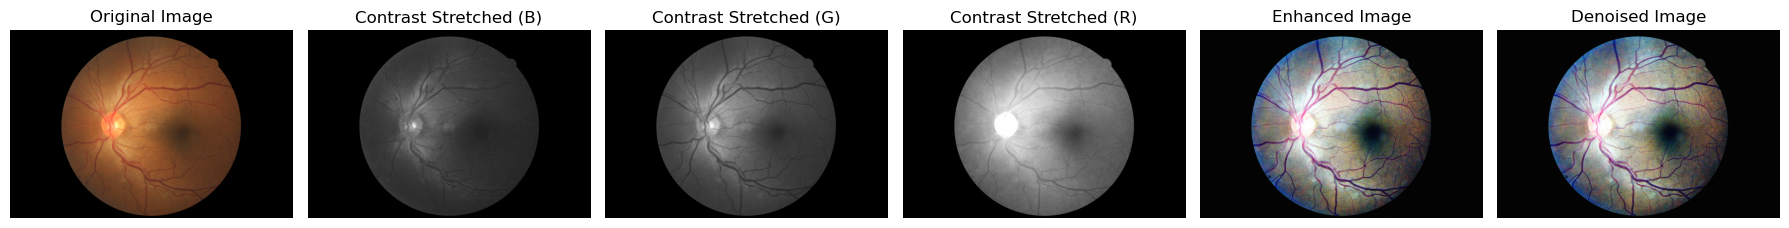

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

directory="C:/Kuliah/ISE/Assignment/Dataset/"
file_name = "17_left.jpeg"
# Load the original color image
image = cv2.imread(directory+file_name, cv2.IMREAD_COLOR)

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

#Split color image
b, g, r = cv2.split(image)

# Apply contrast stretching to each channel
min_b, max_b = np.min(b), np.max(b)
min_g, max_g = np.min(g), np.max(g)
min_r, max_r = np.min(r), np.max(r)

contrast_stretched_b = cv2.convertScaleAbs(b, alpha=255.0/(max_b-min_b), beta=-min_b*255.0/(max_b-min_b))
contrast_stretched_g = cv2.convertScaleAbs(g, alpha=255.0/(max_g-min_g), beta=-min_g*255.0/(max_g-min_g))
contrast_stretched_r = cv2.convertScaleAbs(r, alpha=255.0/(max_r-min_r), beta=-min_r*255.0/(max_r-min_r))

# Apply histogram equalization to each channel
equalized_b = cv2.equalizeHist(contrast_stretched_b)
equalized_g = cv2.equalizeHist(contrast_stretched_g)
equalized_r = cv2.equalizeHist(contrast_stretched_r)

# Apply CLAHE for local contrast enhancement
clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
enhanced_b = clahe.apply(equalized_b)
enhanced_g = clahe.apply(equalized_g)
enhanced_r = clahe.apply(equalized_r)

# Merge the enhanced channels back into the color image
enhanced_image = cv2.merge((enhanced_b, enhanced_g, enhanced_r))

# Apply bilateral filtering for denoising
denoised_image = cv2.bilateralFilter(enhanced_image, d=1, sigmaColor=75, sigmaSpace=75)

# Display the original, normalized, and enhanced images
plt.figure(figsize=(18, 5))

plt.subplot(1, 6, 1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1, 6, 2)
plt.title("Contrast Stretched (B)")
plt.imshow(contrast_stretched_b, cmap='gray')
plt.axis("off")


plt.subplot(1, 6, 3)
plt.title("Contrast Stretched (G)")
plt.imshow(contrast_stretched_g, cmap='gray')
plt.axis("off")

plt.subplot(1, 6, 4)
plt.title("Contrast Stretched (R)")
plt.imshow(contrast_stretched_r, cmap='gray')
plt.axis("off")

plt.subplot(1, 6, 5)
plt.title("Enhanced Image")
plt.imshow(cv2.cvtColor(enhanced_image, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1, 6, 6)
plt.title("Denoised Image")
plt.imshow(cv2.cvtColor(denoised_image, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.tight_layout()
plt.show()



In [101]:
from skimage.metrics import structural_similarity as compare_ssim
from skimage.metrics import peak_signal_noise_ratio as compare_psnr
import numpy as np
import cv2
from matplotlib import pyplot as plt

def calculate_mae(image1, image2):
    # Ensure both images have the same shape
    if image1.shape != image2.shape:
        raise ValueError("Input images must have the same dimensions")

    # Calculate the absolute difference between the two images
    absolute_diff = np.abs(image1 - image2)

    # Calculate the mean of the absolute differences
    mae = np.mean(absolute_diff)

    return mae

def ncc(imgA, imgB):
    # Subtract the mean from each image
    imgA = imgA - np.mean(imgA)
    imgB = imgB - np.mean(imgB)

    # Compute the denominator
    denominator = (np.sqrt(np.sum(imgA ** 2)) * np.sqrt(np.sum(imgB ** 2)))

    # Avoid division by zero
    if denominator == 0:
        return 0
    
    return np.sum(imgA * imgB) / denominator

def image_entropy(image):
    histogram = cv2.calcHist([image], [0], None, [256], [0,256])
    histogram /= histogram.sum()
    entropy = -np.sum(histogram*np.log2(histogram + np.finfo(float).eps))
    return entropy

In [102]:
def display_metrics(original_image, processed_image, description):
    psnr = compare_psnr(original_image, processed_image)
    print(f"{description} - PSNR: {psnr:.4f}")
    
    ssim = compare_ssim(original_image, processed_image, win_size=3, multichannel=True)
    print(f"{description} - SSIM: {ssim:.4f}")

    mae = calculate_mae(original_image, processed_image)
    print(f"{description} - MAE: {mae:.4f}")

    correlation_coefficient = ncc(original_image, processed_image)
    print(f"{description} - NCC: {correlation_coefficient:.4f}")
    
    ori_entropy = image_entropy(original_image[:, :, 0])
    enhanced_entropy = image_entropy(processed_image[:, :, 0])
    print(f"{description} - Original Image Entropy: {ori_entropy:.4f}, Enhanced Image Entropy: {enhanced_entropy:.4f}\n")

In [103]:
display_metrics(image, denoised_image, "")

 - PSNR: 12.3460
 - SSIM: 0.3385
 - MAE: 211.0161
 - NCC: 0.9494
 - Original Image Entropy: 3.5043, Enhanced Image Entropy: 4.7314



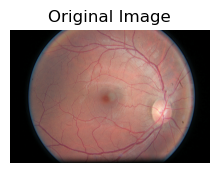

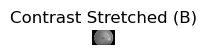

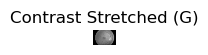

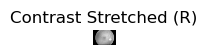

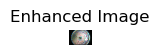

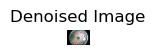

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Your previous code...

# Display the original, normalized, and enhanced images in a single row
plt.figure(figsize=(18, 5))

plt.subplot(1, 6, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis('off')

plt.figure(figsize=(2, 2))

plt.subplot(1, 6, 2)
plt.imshow(contrast_stretched_b, cmap='gray')
plt.title("Contrast Stretched (B)")
plt.axis('off')

plt.figure(figsize=(2, 2))

plt.subplot(1, 6, 3)
plt.imshow(contrast_stretched_g, cmap='gray')
plt.title("Contrast Stretched (G)")
plt.axis('off')

plt.figure(figsize=(2, 2))

plt.subplot(1, 6, 4)
plt.imshow(contrast_stretched_r, cmap='gray')
plt.title("Contrast Stretched (R)")
plt.axis('off')

plt.figure(figsize=(2, 2))

plt.subplot(1, 6, 5)
plt.imshow(cv2.cvtColor(enhanced_image, cv2.COLOR_BGR2RGB))
plt.title("Enhanced Image")
plt.axis('off')

plt.figure(figsize=(2, 2))

plt.subplot(1, 6, 6)
plt.imshow(cv2.cvtColor(denoised_image, cv2.COLOR_BGR2RGB))
plt.title("Denoised Image")
plt.axis('off')

plt.show()
